# 实验一参考答案：国际游客到访量数据处理全流程

> 对应讲次：第1讲 Python 数据处理 × Vibe Coding
>
> 数据集：`../实验一/国际游客到访量.csv`（213 行 × 5 列，20 个国家/地区，2010—2020 年）
>
> 本参考答案展示完整的 Vibe Coding 工作流程。课堂案例仍然使用航天数据，本实验单独使用国际旅游数据。


## 任务1：数据加载与探索性分析（15分）

### Prompt 设计

```text
【氛围段】我拿到了一份国际游客到访量 CSV 数据，需要先全面了解它的结构和统计范围。

【约束段】请帮我：1) 用 pd.read_csv 读取“国际游客到访量.csv”，编码为 utf-8-sig；2) 打印前5行、列名、info、shape、describe；3) 输出国家数、年份范围和区域数；4) 变量名用英文、注释用中文。
```


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

DATA_PATH = Path("../实验一/国际游客到访量.csv")
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("=== 前5行 ===")
print(df.head())
print("\n=== 列名 ===")
print(df.columns.tolist())
print(f"\n数据形状: {df.shape}")
print(f"国家数量: {df['国家'].nunique()}")
print(f"年份范围: {df['年份'].min()}—{df['年份'].max()}")
print(f"世界区域数量: {df['世界区域'].nunique()}")


=== 前5行 ===
       国家 国家代码    年份     国际游客到访量           世界区域
0  Brazil  BRA  2010   5161000.0  South America
1  Canada  CAN  2010  16219000.0  North America
2   China  CHN  2010  55664000.0           Asia
3   Egypt  EGY  2010  14051000.0         Africa
4  France  FRA  2010  76647000.0         Europe

=== 列名 ===
['国家', '国家代码', '年份', '国际游客到访量', '世界区域']

数据形状: (213, 5)
国家数量: 20
年份范围: 2010—2020
世界区域数量: 5


In [2]:
print("=== 数据信息 ===")
df.info()

print("\n=== 描述性统计 ===")
print(df[["年份", "国际游客到访量"]].describe().round(2))


=== 数据信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 213 entries, 0 to 212
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   国家       213 non-null    object 
 1   国家代码     213 non-null    object 
 2   年份       213 non-null    int64  
 3   国际游客到访量  213 non-null    float64
 4   世界区域     213 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.4+ KB

=== 描述性统计 ===
            年份      国际游客到访量
count   213.00       213.00
mean   2015.05  30772739.60
std       3.17  23569314.33
min    2010.00   2086000.00
25%    2012.00  11196000.00
50%    2015.00  24799000.00
75%    2018.00  41684000.00
max    2020.00  90914000.00


### 数据结构说明

该数据集包含 213 行、5 列，记录 20 个国家或地区在 2010—2020 年的国际游客到访情况。每行对应“一个国家在某一年的年度统计记录”，字段包括国家名称、三位国家代码、年份、国际游客到访量和世界区域。国际游客到访量表示到访次数，不等同于独立游客人数。数据是结构化的年度面板数据，2020 年作为特殊年份保留，用于分析国际旅游活动的突变，但不能据此直接推断长期趋势。

### Diff 审查记录

| 检查维度 | 发现 | 处理 |
|---|---|---|
| 结构 | AI 代码可能遗漏 CSV 中文编码参数 | 明确加入 `encoding='utf-8-sig'` |
| 逻辑 | 只打印 `head()` 无法说明面板范围 | 增加国家数、年份范围、区域数 |
| 边界 | 到访量可能被读成字符串 | 使用 `describe()` 和 `dtype` 检查 |


## 任务2：字段检查与数据清洗（30分）

### Round 1 Prompt：类型、缺失值与重复行

```text
【氛围段】数据已经读入，但我需要确认它是否适合比较不同国家的年度旅游变化。

【约束段】请检查列名、数据类型、缺失值和重复行；确认国际游客到访量为数值类型；输出数据质量报告。不要擅自把缺失值填成0。
```


In [3]:
# 类型转换前先保留原始数据副本
clean_df = df.copy()
clean_df["国际游客到访量"] = pd.to_numeric(clean_df["国际游客到访量"], errors="coerce")

quality_report = pd.DataFrame({
    "缺失数": clean_df.isna().sum(),
    "缺失率%": (clean_df.isna().mean() * 100).round(2),
    "数据类型": clean_df.dtypes.astype(str),
})
print("=== 数据质量报告 ===")
print(quality_report)
print(f"\n重复行数: {clean_df.duplicated().sum()}")


=== 数据质量报告 ===
         缺失数  缺失率%     数据类型
国家         0   0.0   object
国家代码       0   0.0   object
年份         0   0.0    int64
国际游客到访量    0   0.0  float64
世界区域       0   0.0   object

重复行数: 0


### Round 2 Prompt：增长率与特殊年份

```text
【氛围段】我想比较每个国家的年度旅游变化，但第一年没有上一年数据，2020 年也可能是特殊冲击年份。

【约束段】请按国家和年份排序，用 groupby + shift 计算上年到访量；增长率按（本年-上年）/上年×100计算；第一年的增长率保留 NaN；增加是否特殊年份字段；打印前10行验证。
```


In [4]:
# 排序后再 shift，确保“上一年”含义正确
clean_df = clean_df.sort_values(["国家", "年份"]).reset_index(drop=True)
clean_df["上年到访量"] = clean_df.groupby("国家")["国际游客到访量"].shift(1)
clean_df["增长率%"] = (
    (clean_df["国际游客到访量"] - clean_df["上年到访量"])
    / clean_df["上年到访量"].replace(0, np.nan)
    * 100
)
clean_df["是否特殊年份"] = clean_df["年份"].eq(2020)

print(clean_df[["国家", "年份", "国际游客到访量", "上年到访量", "增长率%", "是否特殊年份"]].head(10).round(2).to_string(index=False))
print(f"\n第一年增长率缺失数: {clean_df.groupby('国家')['增长率%'].first().isna().sum()}")


    国家   年份   国际游客到访量     上年到访量  增长率%  是否特殊年份
Brazil 2010 5161000.0       NaN   NaN   False
Brazil 2011 5433000.0 5161000.0  5.27   False
Brazil 2012 5677000.0 5433000.0  4.49   False
Brazil 2013 5813000.0 5677000.0  2.40   False
Brazil 2014 6430000.0 5813000.0 10.61   False
Brazil 2015 6306000.0 6430000.0 -1.93   False
Brazil 2016 6547000.0 6306000.0  3.82   False
Brazil 2017 6589000.0 6547000.0  0.64   False
Brazil 2018 6621000.0 6589000.0  0.49   False
Brazil 2019 6353000.0 6621000.0 -4.05   False

第一年增长率缺失数: 0


### Round 3 Prompt：IQR 异常值检测

```text
【氛围段】我还需要识别到访量中的极端值，但统计异常不一定代表业务错误。

【约束段】请对国际游客到访量使用 IQR 方法，输出 Q1、Q3、IQR、正常范围、异常值数量和前5个异常记录；不要直接删除异常值。
```


In [5]:
values = clean_df["国际游客到访量"].dropna()
q1, q3 = values.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_mask = (clean_df["国际游客到访量"] < lower) | (clean_df["国际游客到访量"] > upper)
outliers = clean_df.loc[outlier_mask, ["国家", "年份", "国际游客到访量"]]

print("=== IQR 异常值检测 ===")
print(f"Q1={q1:,.0f}, Q3={q3:,.0f}, IQR={iqr:,.0f}")
print(f"正常范围: [{lower:,.0f}, {upper:,.0f}]")
print(f"异常值数量: {len(outliers)}")
print(outliers.head().to_string(index=False))


=== IQR 异常值检测 ===
Q1=11,196,000, Q3=41,684,000, IQR=30,488,000
正常范围: [-34,536,000, 87,416,000]
异常值数量: 2
    国家   年份    国际游客到访量
France 2018 89322000.0
France 2019 90914000.0


### Diff 审查记录

| 检查维度 | 发现 | 处理 |
|---|---|---|
| 结构 | AI 可能在计算前忘记排序 | 先按国家、年份排序 |
| 逻辑 | 直接 `shift()` 会把不同国家串接起来 | 使用 `groupby('国家').shift(1)` |
| 边界 | 第一年的增长率没有分母 | 保留 NaN；零分母也转为 NaN |
| 解释 | IQR 异常不等于数据错误 | 只标记，不直接删除 |


## 任务3：分组聚合与深度统计（30分）

### Prompt 设计

```text
【氛围段】我想比较不同国家的旅游规模，并观察 2020 年特殊年份对国际游客到访量的影响。

【约束段】请实现：1) 排除2020年后统计各国2010—2019年总到访量Top10；2) 按世界区域计算平均到访量；3) 统计年度总量和同比增长率；4) 选Top3国家画趋势图；5) 计算2019—2020年变化率并输出降幅最大的5个国家；6) 图表使用中文标题和标签。
```


=== 2010—2019 年国际游客到访量 Top10 ===
            国家     国际游客到访量
        France 840589000.0
 United States 728032244.0
         Spain 683608000.0
         China 587799000.0
         Italy 519822200.0
        Turkey 383650000.0
United Kingdom 345388000.0
       Germany 336625000.0
        Mexico 316393000.0
      Thailand 285016000.0


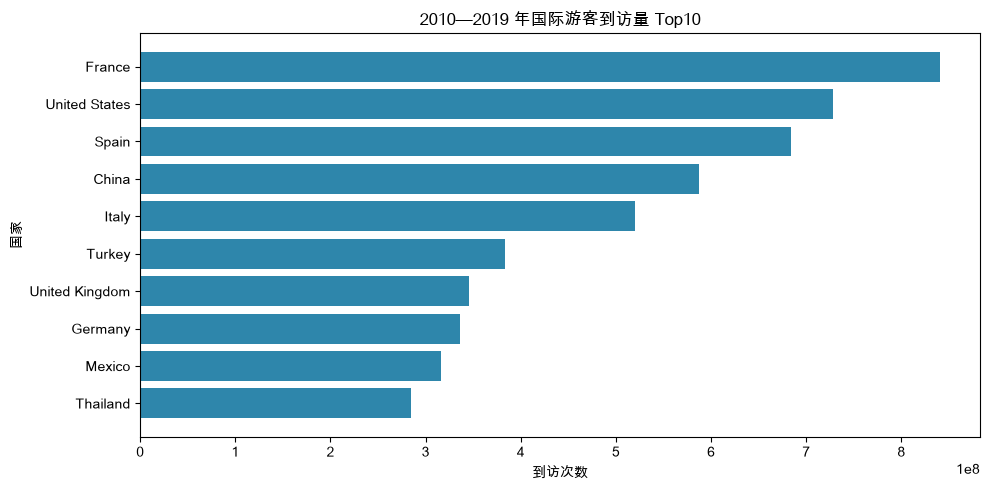

In [6]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.sans-serif": ["Arial Unicode MS", "SimHei", "DejaVu Sans"],
    "axes.unicode_minus": False,
    "figure.dpi": 100,
    "savefig.dpi": 180,
})

analysis_df = clean_df[clean_df["年份"] <= 2019].copy()
country_totals = (
    analysis_df.groupby("国家", as_index=False)["国际游客到访量"]
    .sum()
    .sort_values("国际游客到访量", ascending=False)
)
top10 = country_totals.head(10)
print("=== 2010—2019 年国际游客到访量 Top10 ===")
print(top10.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = top10.sort_values("国际游客到访量")
ax.barh(plot_data["国家"], plot_data["国际游客到访量"], color="#2E86AB")
ax.set_title("2010—2019 年国际游客到访量 Top10")
ax.set_xlabel("到访次数")
ax.set_ylabel("国家")
plt.tight_layout()
plt.show()


In [7]:
region_stats = (
    analysis_df.groupby("世界区域")
    .agg(平均年度到访量=("国际游客到访量", "mean"), 国家数量=("国家", "nunique"))
    .sort_values("平均年度到访量", ascending=False)
)
print("=== 世界区域统计 ===")
print(region_stats.round(0).to_string())

annual = (
    clean_df.groupby("年份", as_index=False)["国际游客到访量"]
    .sum()
    .sort_values("年份")
)
annual["同比增长率%"] = annual["国际游客到访量"].pct_change() * 100
print("\n=== 年度总量与同比增长率 ===")
print(annual.round(2).to_string(index=False))


=== 世界区域统计 ===
                  平均年度到访量  国家数量
世界区域                           
Europe         43788294.0     7
North America  40923675.0     3
Asia           28326222.0     7
Africa          9739590.0     2
South America   6093000.0     1

=== 年度总量与同比增长率 ===
  年份     国际游客到访量  同比增长率%
2010 519782000.0     NaN
2011 544287416.0    4.71
2012 560907900.0    3.05
2013 583587904.0    4.04
2014 615869650.0    5.53
2015 648299520.0    5.27
2016 662147490.0    2.14
2017 695624744.0    5.06
2018 728780120.0    4.77
2019 773877900.0    6.19
2020 221428891.0  -71.39


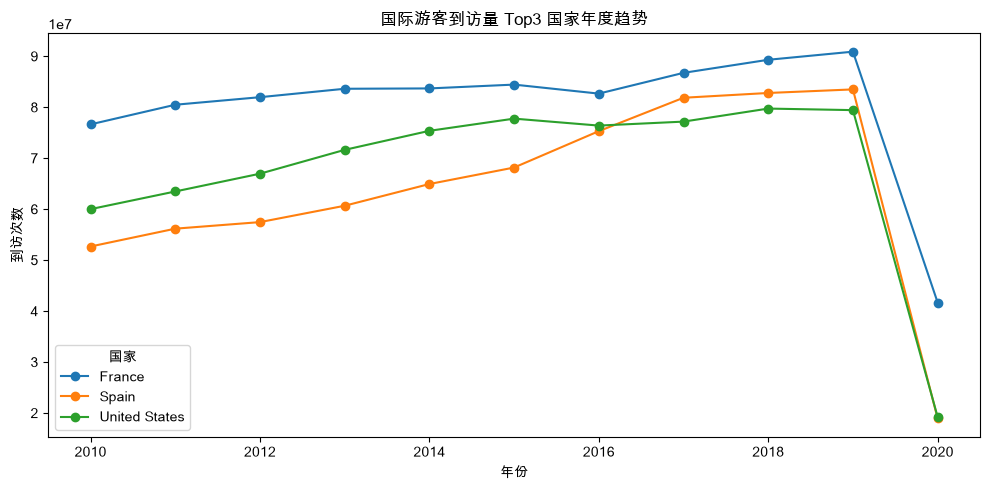

In [8]:
top3 = top10.head(3)["国家"].tolist()
trend = clean_df[clean_df["国家"].isin(top3)].pivot(
    index="年份", columns="国家", values="国际游客到访量"
)

fig, ax = plt.subplots(figsize=(10, 5))
trend.plot(ax=ax, marker="o")
ax.set_title("国际游客到访量 Top3 国家年度趋势")
ax.set_xlabel("年份")
ax.set_ylabel("到访次数")
ax.legend(title="国家")
plt.tight_layout()
plt.show()


=== 2019—2020 年下降幅度 Top5 ===
年份               2019       2020   变化率%
国家                                     
China      65725000.0  7967000.0 -87.88
Canada     22145000.0  2960000.0 -86.63
Singapore  15119000.0  2086000.0 -86.20
India      17754000.0  2699000.0 -84.80
Malaysia   26101000.0  4333000.0 -83.40


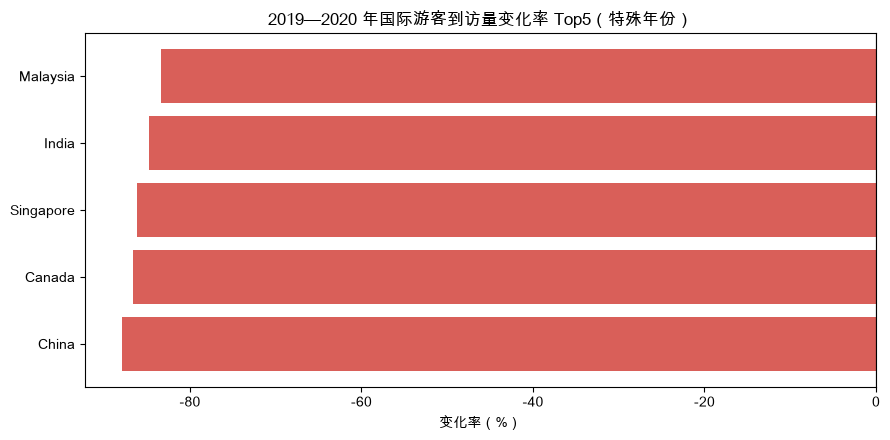

In [9]:
comparison = clean_df[clean_df["年份"].isin([2019, 2020])].pivot(
    index="国家", columns="年份", values="国际游客到访量"
).dropna()
comparison["变化率%"] = (comparison[2020] - comparison[2019]) / comparison[2019] * 100
worst5 = comparison.sort_values("变化率%").head(5)
print("=== 2019—2020 年下降幅度 Top5 ===")
print(worst5.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
plot_data = worst5.sort_values("变化率%")
ax.barh(plot_data.index, plot_data["变化率%"], color="#D95F59")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("2019—2020 年国际游客到访量变化率 Top5（特殊年份）")
ax.set_xlabel("变化率（%）")
plt.tight_layout()
plt.show()


### 结果解释与 Diff 审查记录

- 国家 Top10 的排名口径为 2010—2019 年累计到访量，排除了 2020 年特殊年份，避免排名被突发冲击直接改变。
- 2019—2020 年变化率使用同时存在两个年份的国家，并通过 `pivot()` 对齐，不把缺失年份当成 0。
- 2020 年变化反映特殊年份冲击，不应单独用来判断长期旅游发展趋势。

| 检查维度 | 发现 | 处理 |
|---|---|---|
| 结构 | 条形图和趋势图需要显式导入 matplotlib | 在绘图代码前导入并统一设置字体 |
| 逻辑 | 若先把 2020 年合并到累计排名，可能改变比较口径 | Top10 使用 2010—2019 年数据 |
| 边界 | 2019/2020 缺少任一年份会导致错误变化率 | 使用 `dropna()` 仅保留成对记录 |


## 任务4：AI 辅助综合分析（25分）

### 自选问题

推荐问题：2019 年到访量较高的国家，在 2020 年是否都受到相似程度的冲击？

### Round 1 Prompt

```text
【氛围段】我想了解 2020 年国际旅游受到的冲击。
【约束段】计算每个国家 2019 年和 2020 年到访量的变化率并排序。
```

审查发现：需要检查两个年份是否同时存在，不能把缺失值当成 0。


In [10]:
# Round 1 修正版：先对齐年份，再计算变化率
pair = clean_df[clean_df["年份"].isin([2019, 2020])].pivot(
    index="国家", columns="年份", values="国际游客到访量"
).dropna()
pair["变化率%"] = (pair[2020] - pair[2019]) / pair[2019] * 100
print(pair.sort_values("变化率%").round(2).to_string())


年份                    2019        2020   变化率%
国家                                           
China           65725000.0   7967000.0 -87.88
Canada          22145000.0   2960000.0 -86.63
Singapore       15119000.0   2086000.0 -86.20
India           17754000.0   2699000.0 -84.80
Malaysia        26101000.0   4333000.0 -83.40
Thailand        39916000.0   6725000.0 -83.15
Spain           83509000.0  18933000.0 -77.33
Greece          31348400.0   7374400.0 -76.48
United States   79442000.0  19212120.0 -75.82
Indonesia       15455000.0   3915400.0 -74.67
United Kingdom  39418000.0  10714000.0 -72.82
South Africa    10227500.0   2802000.0 -72.60
Egypt           12876000.0   3619000.0 -71.89
Turkey          51192000.0  15894000.0 -68.95
Germany         39563000.0  12411000.0 -68.63
Brazil           6353000.0   2146435.0 -66.21
Portugal        17283000.0   6480000.0 -62.51
Italy           64513000.0  25190000.0 -60.95
France          90914000.0  41684000.0 -54.15
Mexico          45024000.0  242835

### Round 2 Prompt

```text
【氛围段】上一版结果可能把缺失年份当成 0，影响变化率。
【约束段】只保留同时具有 2019 和 2020 年数据的国家；用 merge 或 pivot 对齐年份；输出变化率和原始到访量。
```

审查发现：逻辑正确，但还需要区分统计变化和疫情背景，不能把一次特殊年份变化解释为长期趋势。


In [11]:
# Round 2：加入 2019 年规模和降幅排名，便于比较“规模—冲击”关系
pair = pair.rename(columns={2019: "2019到访量", 2020: "2020到访量"})
pair["降幅绝对值%"] = -pair["变化率%"]
print(pair.sort_values("变化率%").head(10).round(2).to_string())


年份                2019到访量     2020到访量   变化率%  降幅绝对值%
国家                                                  
China          65725000.0   7967000.0 -87.88   87.88
Canada         22145000.0   2960000.0 -86.63   86.63
Singapore      15119000.0   2086000.0 -86.20   86.20
India          17754000.0   2699000.0 -84.80   84.80
Malaysia       26101000.0   4333000.0 -83.40   83.40
Thailand       39916000.0   6725000.0 -83.15   83.15
Spain          83509000.0  18933000.0 -77.33   77.33
Greece         31348400.0   7374400.0 -76.48   76.48
United States  79442000.0  19212120.0 -75.82   75.82
Indonesia      15455000.0   3915400.0 -74.67   74.67


### Round 3 Prompt

```text
【氛围段】现在需要让结果更容易比较和解释。
【约束段】绘制 2019—2020 年到访量变化率 Top10 条形图，添加零线、数值标签和注释，标题明确写出“特殊年份”，并在结论中说明相关限制。
```


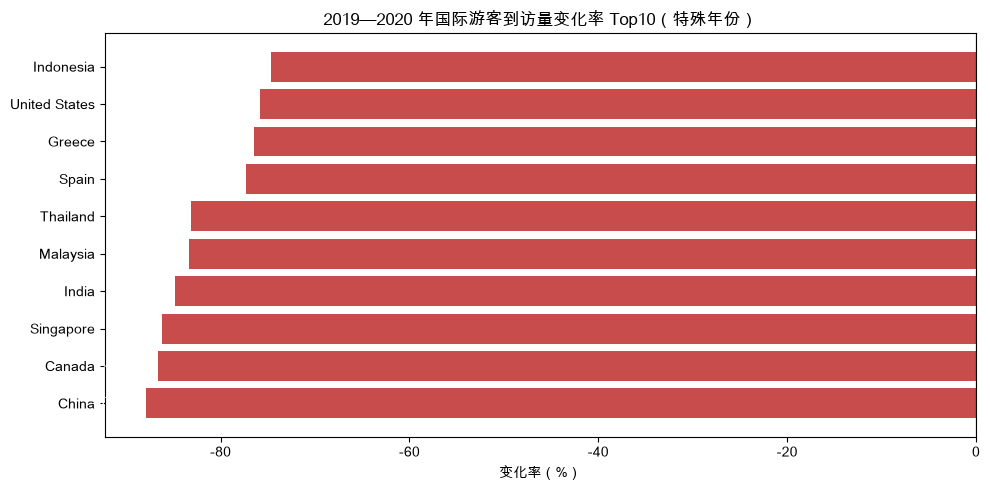

In [12]:
top10_drop = pair.sort_values("变化率%").head(10).sort_values("变化率%")
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top10_drop.index, top10_drop["变化率%"], color="#C94C4C")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("2019—2020 年国际游客到访量变化率 Top10（特殊年份）")
ax.set_xlabel("变化率（%）")
for bar, value in zip(bars, top10_drop["变化率%"]):
    ax.text(value - 1, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", ha="right", color="white")
plt.tight_layout()
plt.show()


### Prompt 迭代总结

| 轮次 | 核心改进 | 审查重点 |
|---:|---|---|
| 1 | 计算 2019—2020 年变化率 | 检查年份是否齐全 |
| 2 | 对齐原始值并增加规模字段 | 避免把缺失当作 0 |
| 3 | 增加排序、零线和数值标注 | 提升可读性，并明确 2020 年限制 |

### 参考结论

本实验数据中，2019—2020 年国际游客到访量整体明显下降，但不同国家的降幅并不完全相同。排名和降幅应以实际运行结果为准；由于 2020 年是全球疫情冲击下的特殊年份，本分析只能描述该年度的统计变化，不能据此断言某个国家长期旅游发展能力下降。


## 思考题参考答案

1. **AI 帮助较大的步骤**：代码框架搭建、字段检查、`groupby`/`shift`/`pivot` 的 API 组合和图表样式调整。**仍需人工判断的步骤**：增长率口径、第一年缺失值处理、2020 年特殊年份的解释和异常值是否为业务错误。
2. **第一年的增长率应保留缺失值**：第一年没有上一年观测值，无法计算变化率；填成 0% 会制造“没有变化”的虚假结论。
3. **2020 年不能直接解释为长期趋势**：它受到全球疫情等外部冲击影响，属于特殊年份，单年变化不等于长期趋势。
4. **常见 AI 问题**：忘记指定中文 CSV 编码、把不同国家的记录直接 `shift`、把缺失年份当作 0、没有对齐 2019/2020 记录、图表缺少单位和零线。避免方法是使用真实文件上下文，并按结构、逻辑、边界三步审查。
